# Tiny Reasoner — Results Analysis

This notebook loads evaluation results from all experiments and generates
comparison plots for the presentation.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

RESULTS_DIR = Path('/Data/iuliia.korotkova/Tiny_Reasoner/results')

In [2]:
# Load all evaluation results
def load_metrics(experiment_name: str) -> dict:
    path = RESULTS_DIR / experiment_name / 'eval_test.json'
    if path.exists():
        with open(path) as f:
            return json.load(f)
    return None

experiments = {
    'SFT Baseline': 'sft_baseline',
}

rows = []
for label, name in experiments.items():
    m = load_metrics(name)
    if m:
        m['experiment'] = label
        rows.append(m)

df = pd.DataFrame(rows)
df

,n_examples,accuracy,format_adherence,has_reasoning,answer_extraction_rate,avg_reasoning_length,experiment
0,1319,0.299469,0.997726,0.997726,0.997726,46.583017,SFT Baseline


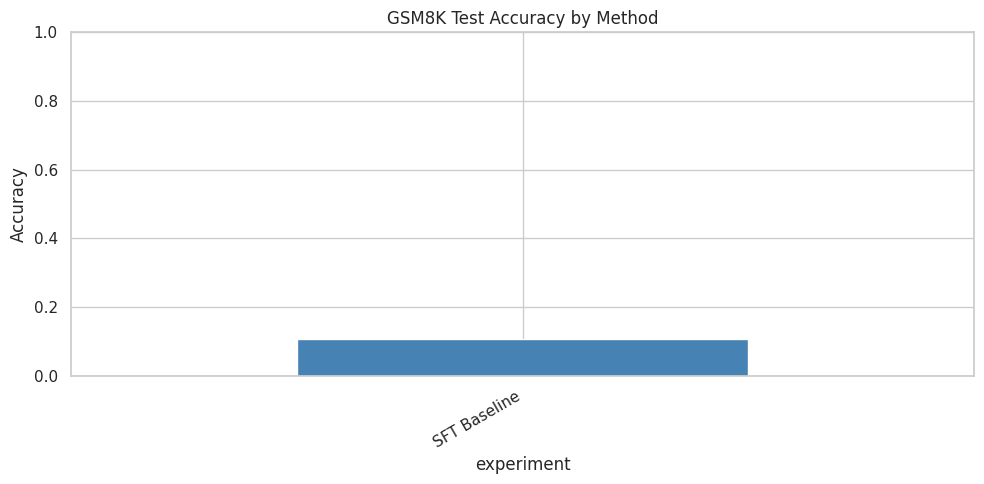

In [16]:
# Accuracy comparison bar chart
fig, ax = plt.subplots(figsize=(10, 5))
df.plot.bar(x='experiment', y='accuracy', ax=ax, color='steelblue', legend=False)
ax.set_ylabel('Accuracy')
ax.set_title('GSM8K Test Accuracy by Method')
ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'accuracy_comparison.png', dpi=150)
plt.show()

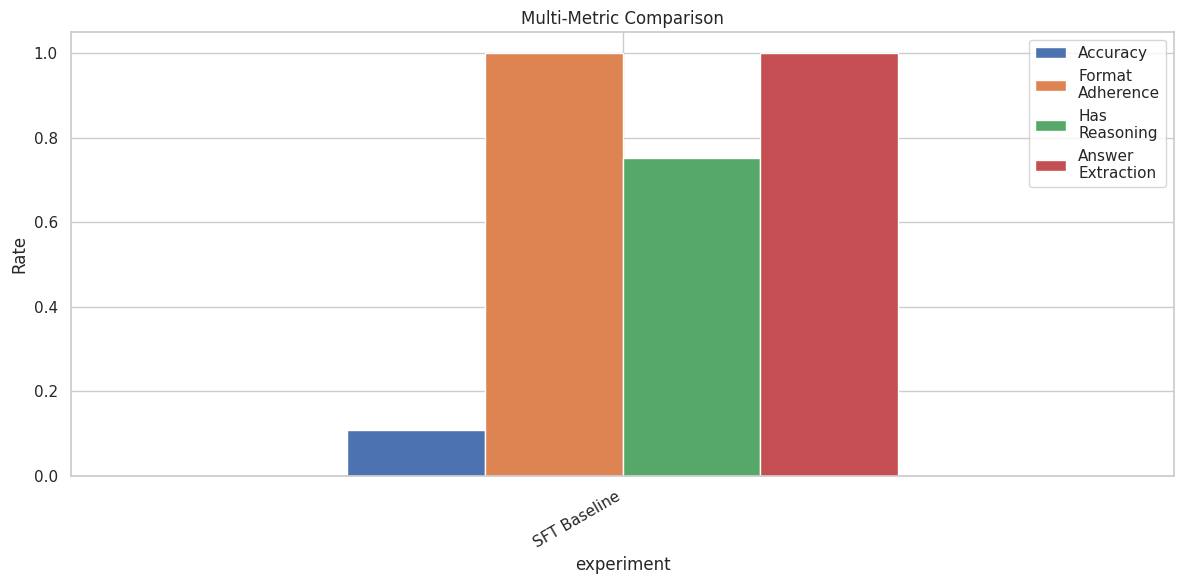

In [17]:
# Multi-metric radar/grouped bar chart
metrics = ['accuracy', 'format_adherence', 'has_reasoning', 'answer_extraction_rate']
metric_labels = ['Accuracy', 'Format\nAdherence', 'Has\nReasoning', 'Answer\nExtraction']

if len(df) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    df[metrics + ['experiment']].set_index('experiment').plot.bar(ax=ax)
    ax.set_ylabel('Rate')
    ax.set_title('Multi-Metric Comparison')
    ax.legend(metric_labels, loc='upper right')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'multi_metric_comparison.png', dpi=150)
    plt.show()

In [3]:
def load_detailed_results(experiment_name: str) -> dict:
    path = RESULTS_DIR / experiment_name / 'eval_test.details.json'
    if path.exists():
        with open(path) as f:
            return json.load(f)
    return None

In [4]:
detailed_results = load_detailed_results("sft_baseline")

In [5]:
detailed_results[0]["question"]

"Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?"

In [6]:
detailed_results[0]["response"]

"<think>\nFirst find how many eggs Janet's ducks lay each day: 16 eggs/day * 3 days/week = 48 eggs/week\nThen add the number of eggs she eats to find the total number of eggs she makes each week: 48 eggs/week + 4 eggs/week = 52 eggs/week\nThen multiply that number by the price per egg to find how much money she gets from selling them: $2/egg * 52 eggs/week = $104/week\n</think>\n<answer>104</answer> </think>"

In [7]:
detailed_results[0]

{'correct': False,
 'has_format': True,
 'has_reasoning': True,
 'predicted_answer': '104.0',
 'reasoning_length': 70,
 'question': "Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?",
 'ground_truth': '18',
 'response': "<think>\nFirst find how many eggs Janet's ducks lay each day: 16 eggs/day * 3 days/week = 48 eggs/week\nThen add the number of eggs she eats to find the total number of eggs she makes each week: 48 eggs/week + 4 eggs/week = 52 eggs/week\nThen multiply that number by the price per egg to find how much money she gets from selling them: $2/egg * 52 eggs/week = $104/week\n</think>\n<answer>104</answer> </think>"}

In [8]:
detailed_results_corr = [res for res in detailed_results if res["correct"]]

In [9]:
detailed_results_corr[0]

{'correct': True,
 'has_format': True,
 'has_reasoning': True,
 'predicted_answer': '3.0',
 'reasoning_length': 18,
 'question': 'A robe takes 2 bolts of blue fiber and half that much white fiber.  How many bolts in total does it take?',
 'ground_truth': '3',
 'response': '<think>\nIt takes 2*0.5=1 bolt of white fiber to make one robe\nSo it takes 2+1=3 blouses per robe\n</think>\n<answer>3</answer>'}